fig 2.b

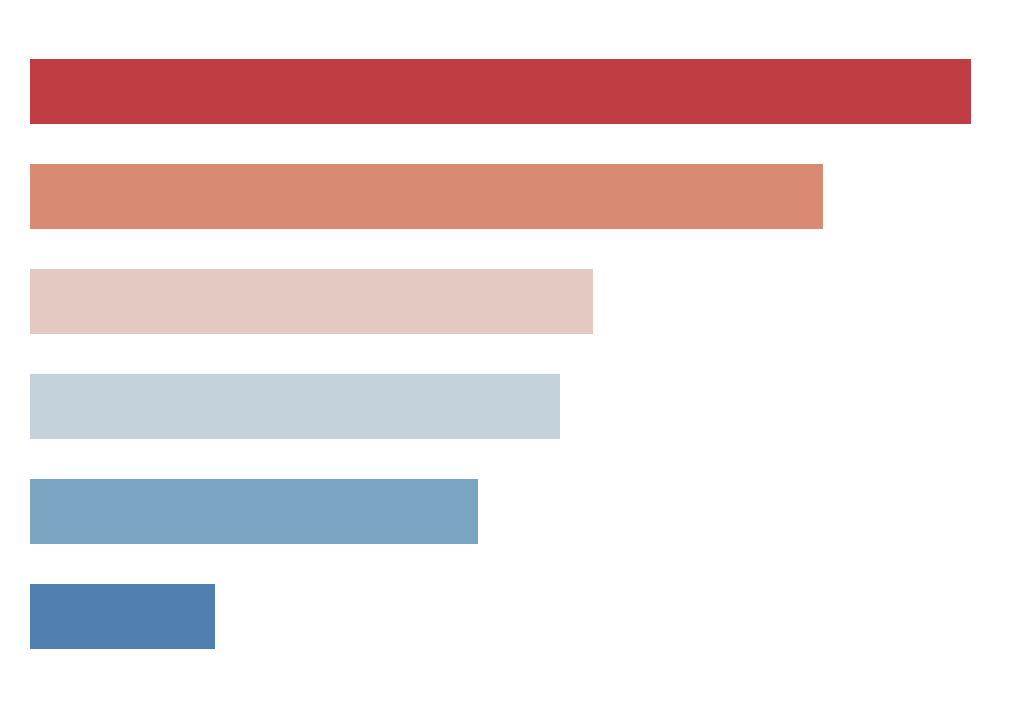

In [16]:
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"

# =========================
# 1. Data
# =========================
data = {
    "Field": [
        "Formats",
        "Interphases",
        "Negative electrodes",
        "Electrolytes",
        "Positive electrodes",
        "Additives",
    ],
    "Accuracy": [
        0.70769,
        0.78974,
        0.81538,
        0.82564,
        0.89744,
        0.94359,
    ],
}

df = pd.DataFrame(data)
df = df.sort_values("Accuracy", ascending=True).reset_index(drop=True)

# =========================
# 2. Nature-style red-blue colors
# =========================
nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#3B6EA8",  # muted blue
        "#7AA6C2",  # light blue
        "#E8E8E8",  # soft neutral
        "#D98B73",  # soft red-orange
        "#B2182B",  # deep red
    ],
)

colors = nature_rb_cmap(np.linspace(0.08, 0.92, len(df)))

# =========================
# 3. Plot body only
# =========================
cm = 1 / 2.54
fig, ax = plt.subplots(figsize=(8.14 * cm, 5.5 * cm), dpi=300)

ax.barh(
    df["Field"],
    df["Accuracy"],
    color=colors,
    linewidth=0,
    height=0.62,
)

# 只保留柱状图本体
ax.set_xlim(0.65, 0.95)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    labelbottom=False,
    labelleft=False,
)

# =========================
# 4. Save
# =========================
os.makedirs("./save_figs", exist_ok=True)
os.makedirs("./figs_data", exist_ok=True)

plt.tight_layout(pad=0)

plt.savefig(
    "./save_figs/fig2_b.svg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0,
)

df.to_csv("./figs_data/fig2_b.csv", index=False)

plt.show()

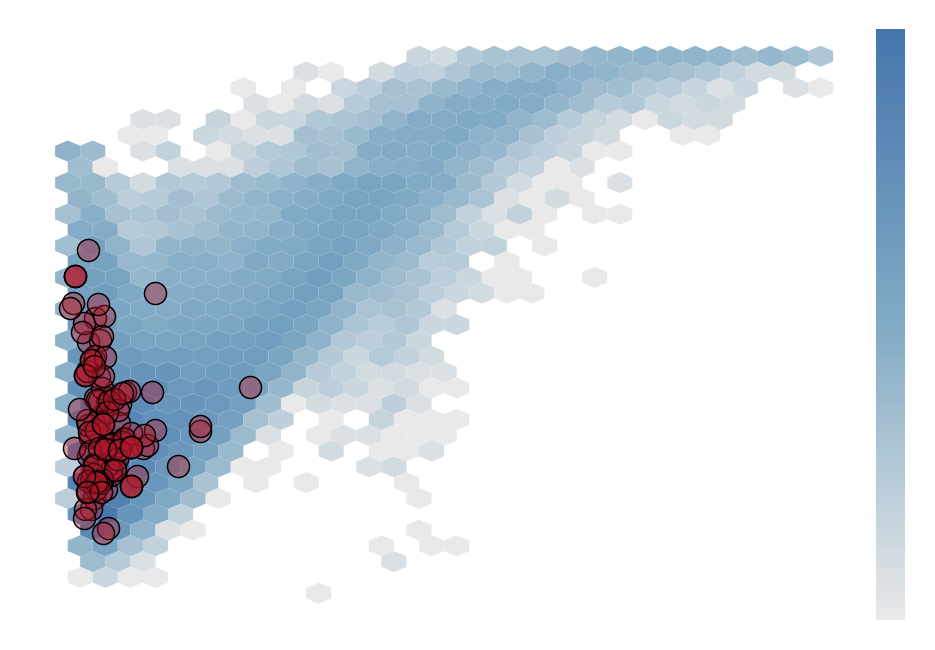

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from matplotlib.colors import LinearSegmentedColormap
import os

# ======================
# Global style
# ======================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"

# ======================
# load data
# ======================
with open('/home/hwx/python_project/test/Boron/V3/plot_data/mass_full.pkl', 'rb') as f:
    mass_full = np.array(pickle.load(f))

with open('/home/hwx/python_project/test/Boron/V3/plot_data/sa_score_full.pkl', 'rb') as f:
    sa_score_full = np.array(pickle.load(f))

with open('/home/hwx/python_project/test/Boron/V3/plot_data/mass_partial.pkl', 'rb') as f:
    mass_partial = np.array(pickle.load(f))

with open('/home/hwx/python_project/test/Boron/V3/plot_data/sa_score_partial.pkl', 'rb') as f:
    sa_score_partial = np.array(pickle.load(f))

select_idx = np.where(mass_partial <= 6000)[0]
mass_partial = mass_partial[select_idx]
sa_score_partial = sa_score_partial[select_idx]

# ======================
# Nature red-blue colors
# ======================
unlabeled_cmap = LinearSegmentedColormap.from_list(
    "unlabeled_blue",
    [
        "#E8E8E8",
        "#7AA6C2",
        "#3B6EA8",
    ],
)

positive_color = "#B2182A67"

# ======================
# plot
# ======================
cm = 1 / 2.54
fig, ax = plt.subplots(
    figsize=(7.5 * cm, 5.0 * cm),
    dpi=300
)

# unlabeled samples: blue density
hb = ax.hexbin(
    mass_partial,
    sa_score_partial,
    gridsize=30,
    cmap=unlabeled_cmap,
    bins="log",
    mincnt=1,
    alpha=0.95,
    linewidths=0
)

# positive samples: red dots
ax.scatter(
    mass_full,
    sa_score_full,
    color=positive_color,
    s=28,
    marker="o",
    edgecolors="black",
    linewidth=0.35,
)

# ======================
# colorbar: only color strip, no ticks/values
# ======================
cb = fig.colorbar(
    hb,
    ax=ax,
    fraction=0.045,
    pad=0.02
)

cb.set_label("")
cb.set_ticks([])
cb.ax.set_yticks([])
cb.ax.set_yticklabels([])

cb.ax.tick_params(
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
    length=0,
    width=0
)

cb.outline.set_visible(False)

# ======================
# remove all axes/text
# ======================
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    labelbottom=False,
    labelleft=False,
)

# ======================
# Save
# ======================
os.makedirs("./save_figs", exist_ok=True)
os.makedirs("./figs_data", exist_ok=True)

plt.tight_layout(pad=0)

plt.savefig(
    "./save_figs/fig2_d.svg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

# ======================
# Save plotting data
# ======================
fig2_d_positive_df = pd.DataFrame({
    "group": "positive",
    "mass": mass_full,
    "sa_score": sa_score_full,
})

fig2_d_unlabeled_df = pd.DataFrame({
    "group": "unlabeled",
    "mass": mass_partial,
    "sa_score": sa_score_partial,
})

fig2_d_df = pd.concat(
    [fig2_d_positive_df, fig2_d_unlabeled_df],
    ignore_index=True
)

fig2_d_df.to_csv("./figs_data/fig2_d.csv", index=False)

In [2]:
import pickle


data_path = '/home/hwx/python_project/test/Boron/data/all_data.pkl'
with open(data_path, 'rb') as f:
    all_data = pickle.load(f)

positive_samples = all_data[:126] # number of positive samples
unlabeled_samples = all_data[126:]

print(positive_samples[0])

Data(x=[16, 79], edge_index=[2, 30], edge_attr=[30, 16], id=0, n_nodes=16, n_edges=30)


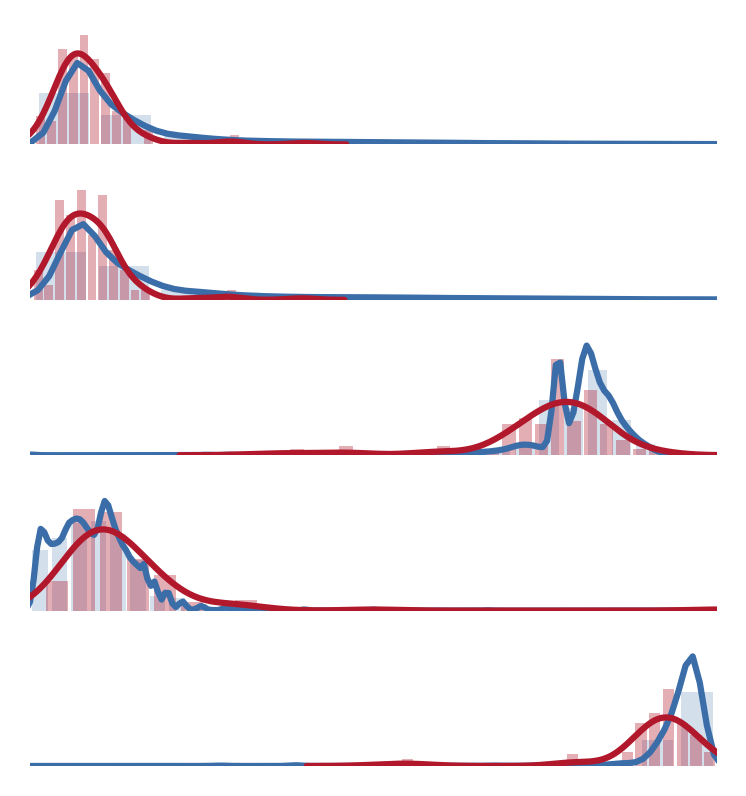

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ============================================================
# 1. Extract graph-level properties
# ============================================================

def compute_degree_array(n, edge_index, edge_is_bidirectional=True):
    edges = edge_index.cpu().numpy() if hasattr(edge_index, "cpu") else np.asarray(edge_index)
    degree = np.zeros(n, dtype=np.float32)

    if edge_is_bidirectional:
        undirected_edges = set()
        for u, v in edges.T:
            u, v = int(u), int(v)
            if u < 0 or v < 0 or u >= n or v >= n or u == v:
                continue
            undirected_edges.add(tuple(sorted((u, v))))

        for u, v in undirected_edges:
            degree[u] += 1
            degree[v] += 1
    else:
        for u, v in edges.T:
            u, v = int(u), int(v)
            if u < 0 or v < 0 or u >= n or v >= n or u == v:
                continue
            degree[u] += 1
            degree[v] += 1

    return degree


def compute_degree_entropy(degree):
    degree = np.asarray(degree, dtype=np.float32)
    total_degree = np.sum(degree)

    if total_degree <= 0 or len(degree) <= 1:
        return 0.0

    p = degree / total_degree
    p = p[p > 0]

    entropy = -np.sum(p * np.log(p + 1e-12))
    return entropy / np.log(len(degree) + 1e-12)


def get_graph_level_properties(dataset, edge_is_bidirectional=True):
    num_atoms = []
    num_bonds = []
    avg_degree = []
    graph_density = []
    degree_entropy = []

    for data in dataset:
        n = int(data.n_nodes) if hasattr(data, "n_nodes") else int(data.x.shape[0])

        if hasattr(data, "n_edges"):
            e_raw = int(data.n_edges)
        elif hasattr(data, "edge_index"):
            e_raw = int(data.edge_index.shape[1])
        else:
            raise AttributeError("Data object must have n_edges or edge_index.")

        e = e_raw / 2.0 if edge_is_bidirectional else e_raw

        num_atoms.append(n)
        num_bonds.append(e)
        avg_degree.append(2.0 * e / max(n, 1))
        graph_density.append(2.0 * e / (n * (n - 1) + 1e-8))

        if hasattr(data, "edge_index"):
            degree = compute_degree_array(
                n=n,
                edge_index=data.edge_index,
                edge_is_bidirectional=edge_is_bidirectional
            )
            entropy = compute_degree_entropy(degree)
        else:
            entropy = 0.0

        degree_entropy.append(entropy)

    return {
        "Atoms": np.array(num_atoms),
        "Bonds": np.array(num_bonds),
        "Average degree": np.array(avg_degree),
        "Graph density": np.array(graph_density),
        "Degree entropy": np.array(degree_entropy),
    }


positive_props = get_graph_level_properties(
    positive_samples,
    edge_is_bidirectional=True
)

unlabeled_props = get_graph_level_properties(
    unlabeled_samples,
    edge_is_bidirectional=True
)

# ============================================================
# 2. Plot settings
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"
sns.set_theme(style="white")

nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#3B6EA8",  # muted blue
        "#7AA6C2",  # light blue
        "#E8E8E8",  # soft neutral
        "#D98B73",  # soft red-orange
        "#B2182B",  # deep red
    ],
)

unlabeled_color = "#3B6EA8"
positive_color = "#B2182B"

metrics = [
    "Atoms",
    "Bonds",
    "Average degree",
    "Graph density",
    "Degree entropy",
]

xlim_dict = {
    "Atoms": (0, 250),
    "Bonds": (0, 250),
    "Average degree": (0.0, 2.6),
    "Graph density": (0.0, 1.0),
    "Degree entropy": (0.5, 1.0),
}

num_xticks = 6
xticks_dict = {
    metric: np.linspace(xlim_dict[metric][0], xlim_dict[metric][1], num_xticks)
    for metric in metrics
}

# ============================================================
# 3. Figure size: width 7.5 cm, height 8.1 cm
# ============================================================

cm = 1 / 2.54

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(7.5 * cm, 8.1 * cm),
    dpi=300,
    gridspec_kw={
        "height_ratios": [1, 1, 1, 1, 1],
        "hspace": 0.35
    }
)

# ============================================================
# 4. Plot stacked distributions
# ============================================================

for ax, metric in zip(axes, metrics):
    x_pos = positive_props[metric]
    x_unl = unlabeled_props[metric]

    x_pos = x_pos[np.isfinite(x_pos)]
    x_unl = x_unl[np.isfinite(x_unl)]

    sns.histplot(
        x_unl,
        bins=35,
        stat="density",
        color=unlabeled_color,
        alpha=0.22,
        edgecolor=None,
        linewidth=0,
        ax=ax,
        shrink=0.8,
    )

    sns.histplot(
        x_pos,
        bins=25,
        stat="density",
        color=positive_color,
        alpha=0.35,
        edgecolor=None,
        linewidth=0,
        ax=ax,
        shrink=0.82,
    )

    if len(np.unique(x_unl)) > 1:
        sns.kdeplot(
            x_unl,
            color=unlabeled_color,
            linewidth=1.5,
            ax=ax,
            clip_on=True
        )

    if len(np.unique(x_pos)) > 1:
        sns.kdeplot(
            x_pos,
            color=positive_color,
            linewidth=1.5,
            ax=ax,
            clip_on=True
        )

    ax.set_xlim(xlim_dict[metric])
    ax.set_xticks(xticks_dict[metric])

    # 隐藏文字，但保留边框和x轴刻度线
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])

    # ====================================
    # remove all axes / ticks / borders
    # ====================================

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticks([])
    ax.set_yticks([])

    ax.tick_params(
        axis="both",
        which="both",
        bottom=False,
        top=False,
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
        length=0,
        width=0,
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

# ============================================================
# 5. Save
# ============================================================

os.makedirs("./save_figs", exist_ok=True)
os.makedirs("./figs_data", exist_ok=True)

plt.subplots_adjust(hspace=0.35)

plt.savefig(
    "./save_figs/fig2_e.svg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

# ============================================================
# 6. Save plotting data
# ============================================================

all_df_list = []

for metric in metrics:
    all_df_list.append(pd.DataFrame({
        "metric": metric,
        "group": "positive",
        "value": positive_props[metric]
    }))

    all_df_list.append(pd.DataFrame({
        "metric": metric,
        "group": "unlabeled",
        "value": unlabeled_props[metric]
    }))

fig2_e_df = pd.concat(all_df_list, ignore_index=True)

fig2_e_df.to_csv(
    "./figs_data/fig2_e.csv",
    index=False
)

Node positive shape: (2720, 79)
Node unlabeled shape: (7409712, 79)

Full node feature mapping:
   feature  feature_index          physical_meaning
0       N0              0                         C
1       N1              1                         N
2       N2              2                         O
3       N3              3                         S
4       N4              4                         F
..     ...            ...                       ...
74     N74             74             n_hydrogens_1
75     N75             75             n_hydrogens_2
76     N76             76             n_hydrogens_3
77     N77             77             n_hydrogens_4
78     N78             78  n_hydrogens_MoreThanFour

[79 rows x 3 columns]

Node feature dimension: 79

Selected top node feature dims: [67 68 65 59  0 74 64 73 60  4 46 45 52 44  2]

Top node feature shifts:
   feature  feature_index        physical_meaning  positive  unlabeled  \
0      N67             67       vdw_radius_scaled

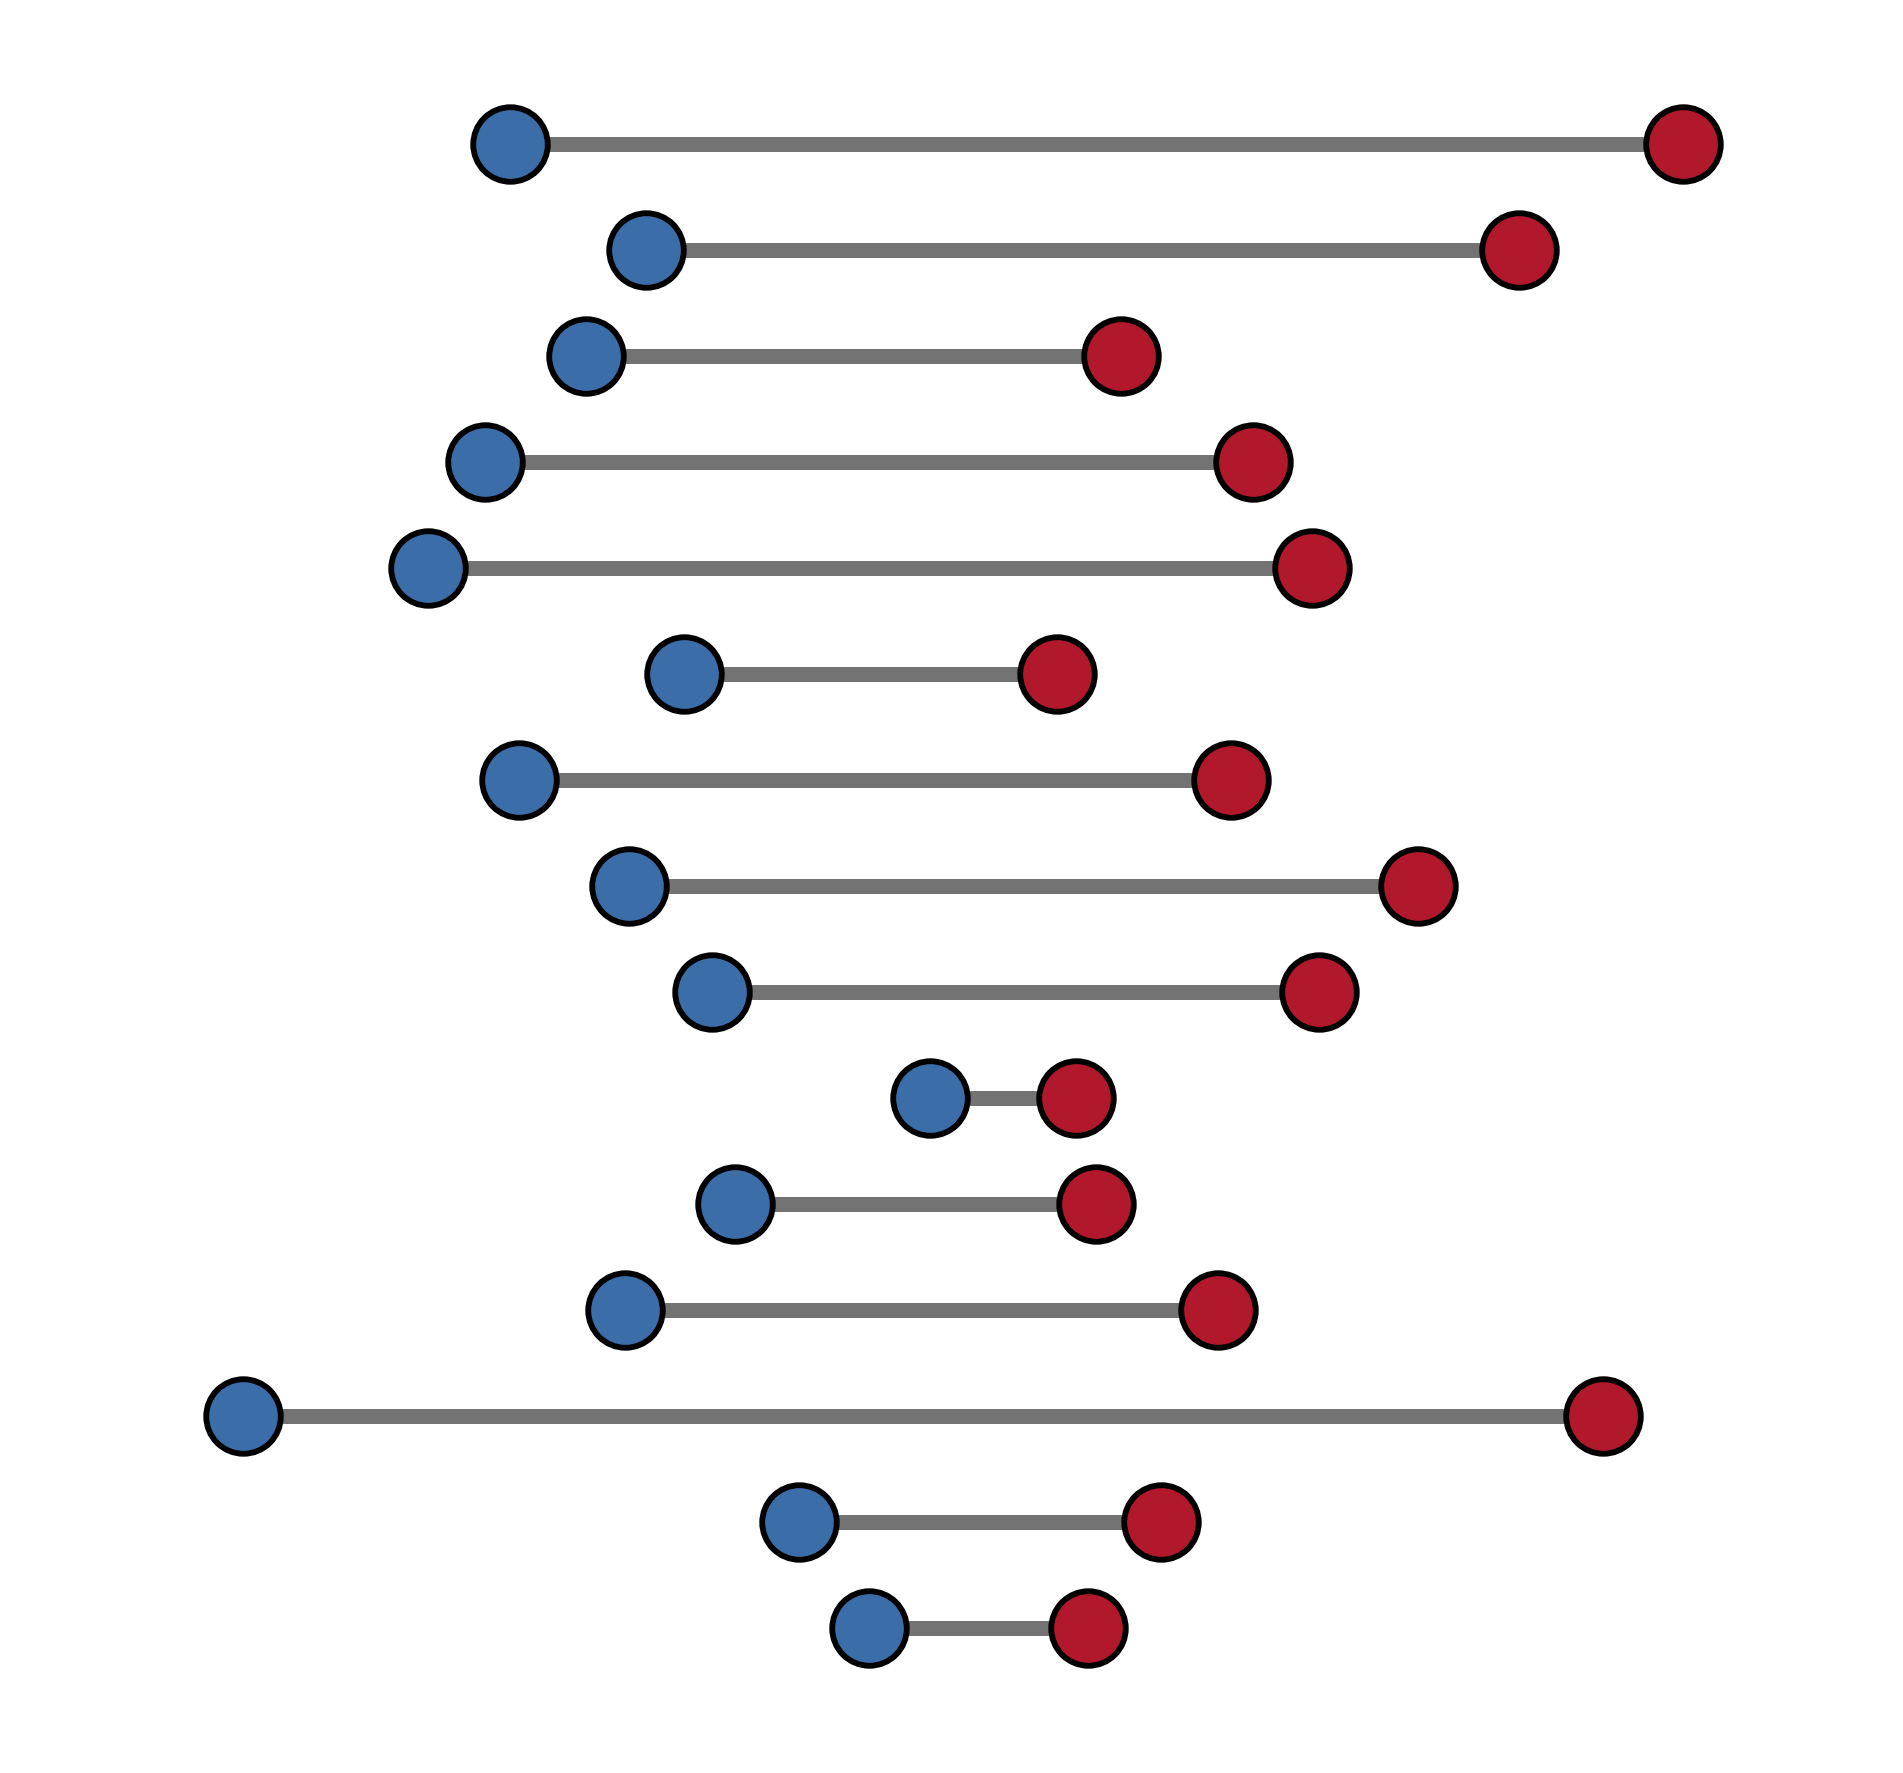


Saved files:
./save_figs/fig2_f.svg
./figs_data/fig2_f.csv
./figs_data/fig2_f_node_feature_mapping.csv


In [3]:
# -*- coding: utf-8 -*-

import os
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


# ============================================================
# 1. Settings
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"
sns.set_theme(style="white")

OUT_DIR = "./save_figs"
DATA_DIR = "./figs_data"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#3B6EA8",  # muted blue
        "#7AA6C2",  # light blue
        "#E8E8E8",  # soft neutral
        "#D98B73",  # soft red-orange
        "#B2182B",  # deep red
    ],
)

unlabeled_color = nature_rb_cmap(0.00)   # blue
positive_color = nature_rb_cmap(1.00)    # red

NODE_TOP_K = 15


# ============================================================
# 2. Node feature physical meanings
# ============================================================

physical_feature_names = [
    'C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg',
    'Na', 'Ca', 'Fe', 'As', 'Al', 'I', 'B', 'V', 'K', 'Tl',
    'Yb', 'Sb', 'Sn', 'Ag', 'Pd', 'Co', 'Se', 'Ti', 'Zn', 'Li',
    'Ge', 'Cu', 'Au', 'Ni', 'Cd', 'In', 'Mn', 'Zr', 'Cr', 'Pt',
    'Hg', 'Pb', 'Unknown',
    'n_heavy_neighbors_0', 'n_heavy_neighbors_1', 'n_heavy_neighbors_2',
    'n_heavy_neighbors_3', 'n_heavy_neighbors_4', 'n_heavy_neighbors_MoreThanFour',
    'formal_charge_-3', 'formal_charge_-2', 'formal_charge_-1',
    'formal_charge_0', 'formal_charge_1', 'formal_charge_2',
    'formal_charge_3', 'formal_charge_Extreme',
    'S', 'SP', 'SP2', 'SP3', 'SP3D', 'SP3D2', 'OTHER',
    'is_in_a_ring', 'is_aromatic',
    'atomic_mass_scaled', 'vdw_radius_scaled', 'covalent_radius_scaled',
    'CHI_UNSPECIFIED', 'CHI_TETRAHEDRAL_CW', 'CHI_TETRAHEDRAL_CCW', 'CHI_OTHER',
    'n_hydrogens_0', 'n_hydrogens_1', 'n_hydrogens_2',
    'n_hydrogens_3', 'n_hydrogens_4', 'n_hydrogens_MoreThanFour'
]


# ============================================================
# 3. Utility functions
# ============================================================

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def collect_feature_matrix(dataset, attr_name):
    feature_list = []

    for data in dataset:
        if not hasattr(data, attr_name):
            continue

        feat = getattr(data, attr_name)

        if feat is None:
            continue

        feat = to_numpy(feat)

        if feat.ndim != 2:
            continue

        feature_list.append(feat)

    if len(feature_list) == 0:
        raise ValueError(f"No valid feature matrix found for {attr_name}")

    return np.concatenate(feature_list, axis=0)


def compute_feature_composition(feature_matrix, eps=1e-12):
    feature_matrix = np.asarray(feature_matrix, dtype=float)

    if np.nanmin(feature_matrix) < 0:
        mean_feat = np.nanmean(np.abs(feature_matrix), axis=0)
    else:
        mean_feat = np.nanmean(feature_matrix, axis=0)

    comp = mean_feat / (np.sum(mean_feat) + eps)

    return mean_feat, comp


def select_top_diff_features(comp_pos, comp_unl, top_k):
    diff = np.abs(comp_pos - comp_unl)
    selected_idx = np.argsort(diff)[::-1][:top_k]
    return selected_idx


def build_node_feature_df(comp_pos, comp_unl, selected_idx, nx_names, physical_names):
    df = pd.DataFrame({
        "feature": [nx_names[i] for i in selected_idx],
        "feature_index": selected_idx,
        "physical_meaning": [physical_names[i] for i in selected_idx],
        "positive": comp_pos[selected_idx],
        "unlabeled": comp_unl[selected_idx],
    })

    df["delta"] = df["positive"] - df["unlabeled"]
    df["abs_delta"] = df["delta"].abs()

    df = df.sort_values("abs_delta", ascending=False).reset_index(drop=True)

    return df


def build_full_feature_mapping(nx_names, physical_names):
    mapping_df = pd.DataFrame({
        "feature": nx_names,
        "feature_index": np.arange(len(nx_names)),
        "physical_meaning": physical_names,
    })

    return mapping_df


def plot_node_mirrored_dumbbell(ax, df_plot):
    n_total = len(df_plot)
    y = np.arange(n_total)

    x_left = -df_plot["unlabeled"].values
    x_right = df_plot["positive"].values

    for i in range(n_total):
        ax.hlines(
            y=i,
            xmin=x_left[i],
            xmax=x_right[i],
            color="black",
            linewidth=1.8,
            alpha=0.55,
            zorder=2
        )

        ax.scatter(
            x_left[i],
            i,
            s=80,
            c=[unlabeled_color],
            edgecolors="black",
            linewidths=0.7,
            marker="o",
            zorder=3
        )

        ax.scatter(
            x_right[i],
            i,
            s=80,
            c=[positive_color],
            edgecolors="black",
            linewidths=0.7,
            marker="o",
            zorder=3
        )

    max_comp = max(df_plot["positive"].max(), df_plot["unlabeled"].max()) * 1.22
    ax.set_xlim(-max_comp, max_comp)

    ax.set_ylim(-0.8, n_total - 0.2)
    ax.invert_yaxis()

    ax.set_axis_off()


# ============================================================
# 4. Collect node features
# ============================================================

node_pos = collect_feature_matrix(positive_samples, "x")
node_unl = collect_feature_matrix(unlabeled_samples, "x")

print("Node positive shape:", node_pos.shape)
print("Node unlabeled shape:", node_unl.shape)


# ============================================================
# 5. Check feature dimension
# ============================================================

node_dim = node_pos.shape[1]

if node_unl.shape[1] != node_dim:
    raise ValueError(
        f"Feature dimension mismatch: positive={node_dim}, unlabeled={node_unl.shape[1]}"
    )

if len(physical_feature_names) != node_dim:
    raise ValueError(
        f"Feature name number mismatch: feature dimension={node_dim}, "
        f"but physical_feature_names has {len(physical_feature_names)} names."
    )

# 图和 top-15 表中仍然使用 N0, N1, N2...
node_feature_names = [f"N{i}" for i in range(node_dim)]


# ============================================================
# 6. Save full feature mapping
# ============================================================

node_mapping_df = build_full_feature_mapping(
    node_feature_names,
    physical_feature_names
)

node_mapping_df.to_csv(
    os.path.join(DATA_DIR, "fig2_f_node_feature_mapping.csv"),
    index=False
)

print("\nFull node feature mapping:")
print(node_mapping_df)


# ============================================================
# 7. Compute node feature compositions
# ============================================================

node_mean_pos, node_comp_pos = compute_feature_composition(node_pos)
node_mean_unl, node_comp_unl = compute_feature_composition(node_unl)

print("\nNode feature dimension:", len(node_comp_pos))


# ============================================================
# 8. Select top node features
# ============================================================

node_selected_idx = select_top_diff_features(
    node_comp_pos,
    node_comp_unl,
    top_k=NODE_TOP_K
)

print("\nSelected top node feature dims:", node_selected_idx)

node_df = build_node_feature_df(
    node_comp_pos,
    node_comp_unl,
    node_selected_idx,
    nx_names=node_feature_names,
    physical_names=physical_feature_names
)

print("\nTop node feature shifts:")
print(node_df)


# ============================================================
# 9. Plot
# ============================================================

cm_to_inch = 1 / 2.54

fig, ax = plt.subplots(
    figsize=(7.55 * cm_to_inch, 7.0 * cm_to_inch),
    dpi=600
)

plot_node_mirrored_dumbbell(ax, node_df)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.savefig(
    os.path.join(OUT_DIR, "fig2_f.svg"),
    format="svg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()


# ============================================================
# 10. Save plotting data to CSV
# ============================================================

node_df.to_csv(
    os.path.join(DATA_DIR, "fig2_f.csv"),
    index=False
)

print("\nSaved files:")
print(os.path.join(OUT_DIR, "fig2_f.svg"))
print(os.path.join(DATA_DIR, "fig2_f.csv"))
print(os.path.join(DATA_DIR, "fig2_f_node_feature_mapping.csv"))

/tmp/ipykernel_3922146/963541183.py:70: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  unlabeled_df = pd.read_csv("../data/searching_space_data_V2.csv")


Valid positive SMILES: 126
Valid unlabeled SMILES: 179981
Positive used for plot: 126
Unlabeled used for plot: 30000


  0%|          | 0/30000 [00:00<?, ?it/s][10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
  2%|▏         | 660/30000 [00:00<00:09, 3128.95it/s][10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
[10:40:05] WARNING: not removing hydrogen atom without neighbors
  3%|▎         | 989/30000 [00:00<00:09, 3198.08it/s][10:40:0

Positive fingerprint shape: (126, 2048)
Unlabeled fingerprint shape: (29972, 2048)


/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/hwx/envs/boron/lib/python3.9/site-packages/pynndescent/pynndescent_.py:939: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(


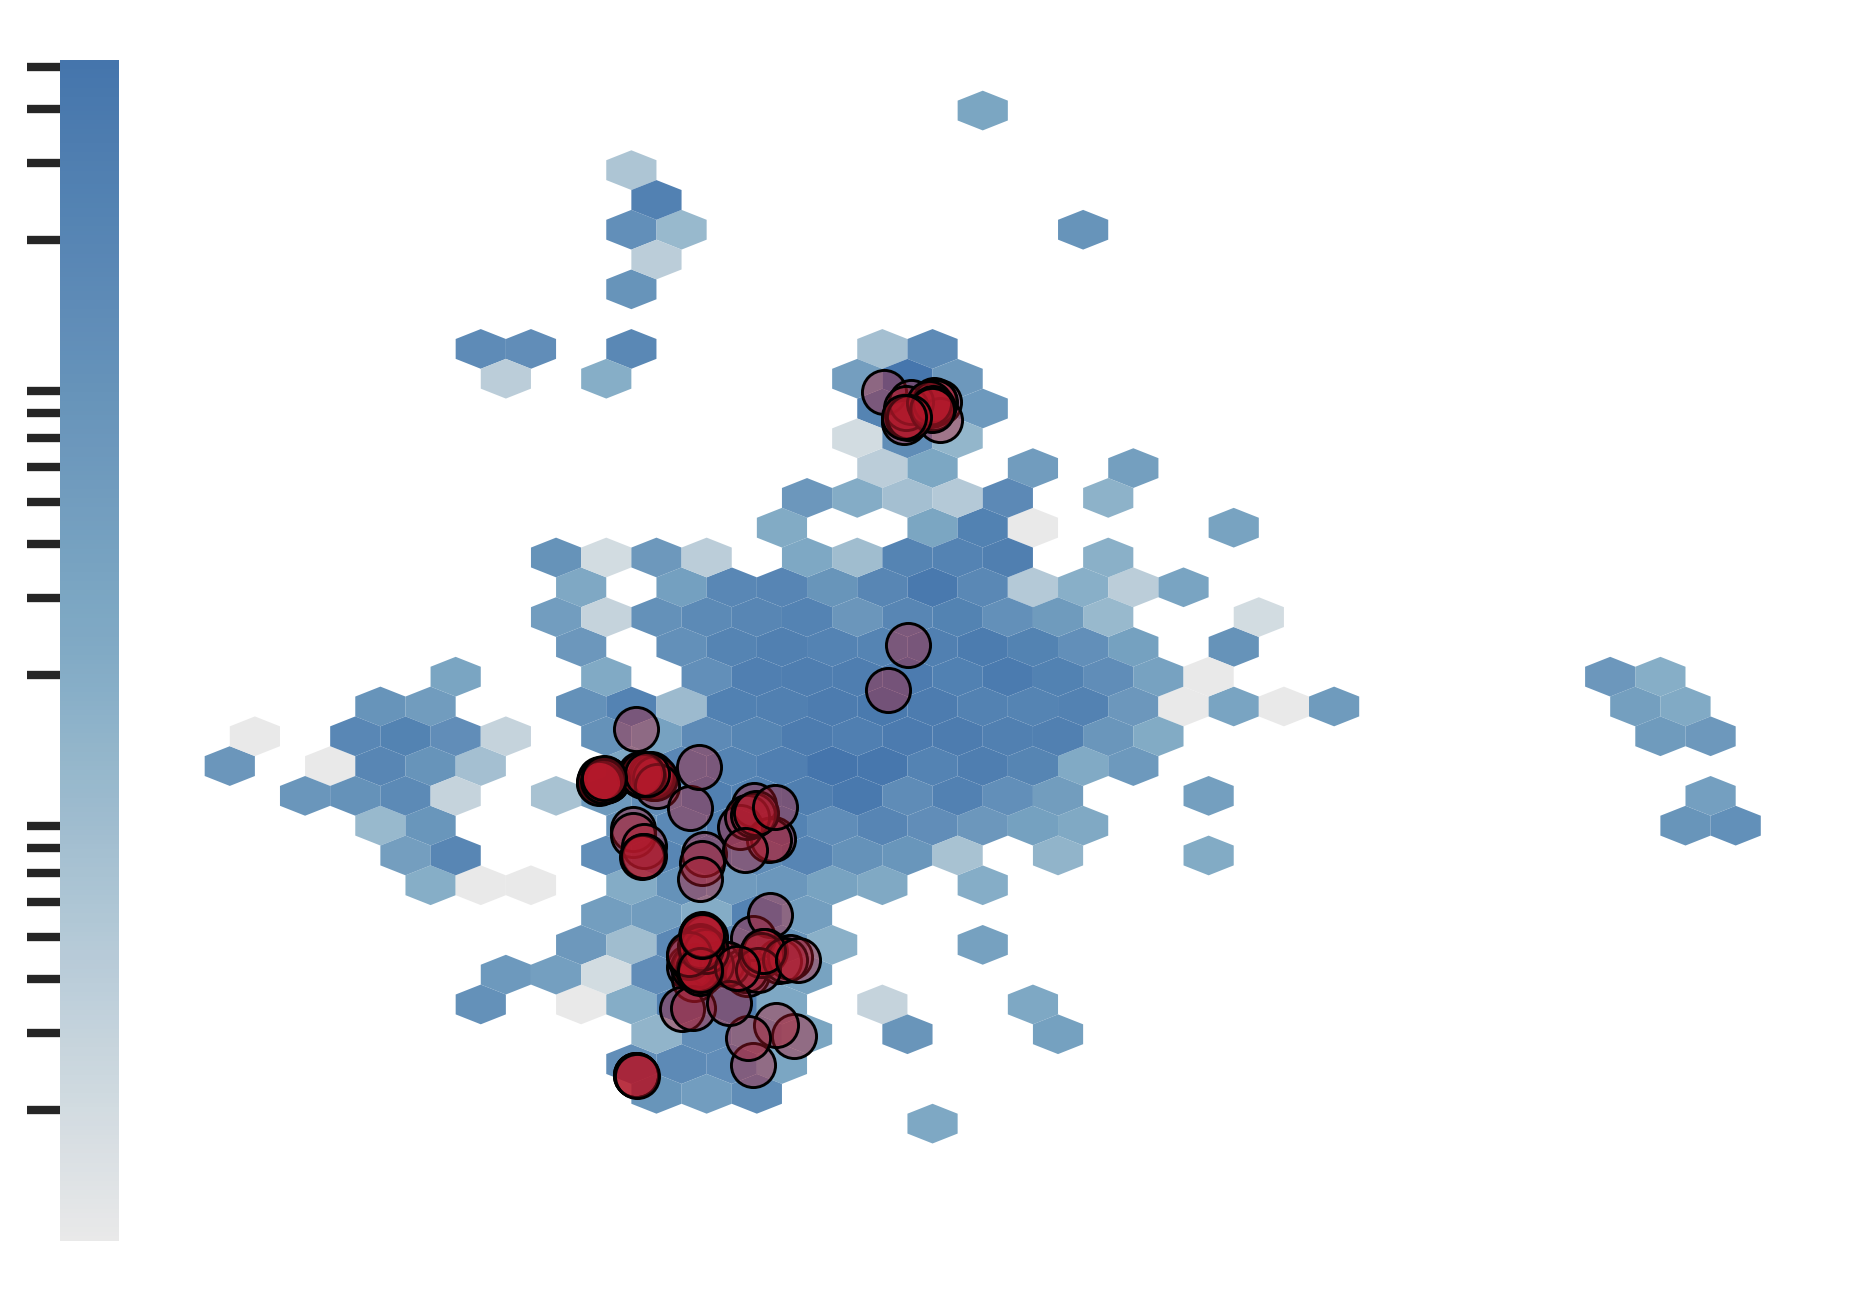

In [ ]:
# -*- coding: utf-8 -*-

import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from tqdm import tqdm
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("Warning: umap-learn is not installed. PCA will be used instead.")


# ============================================================
# 1. Settings
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"
sns.set_theme(style="white")

OUT_DIR = "./save_figs"
DATA_DIR = "./figs_data"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#E8E8E8",
        "#7AA6C2",
        "#3B6EA8",
    ],
)

unlabeled_color = "#3B6EA8"
positive_color = "#B2182A67"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

MORGAN_RADIUS = 2
MORGAN_NBITS = 2048

MAX_UNLABELED_FOR_UMAP = 30000
MAX_POSITIVE_FOR_UMAP = None


# ============================================================
# 2. Extract SMILES
# ============================================================

with open("../data/additives.json", "r") as file:
    additives_data = json.load(file)

positive_smiles = [i["smiles"] for i in additives_data.values()]

unlabeled_df = pd.read_csv("../data/searching_space_data_V2.csv")
unlabeled_smiles = unlabeled_df["SMILES"].tolist()

print("Valid positive SMILES:", len(positive_smiles))
print("Valid unlabeled SMILES:", len(unlabeled_smiles))


# ============================================================
# 3. Optional sampling
# ============================================================

def random_sample_list(x, max_n=None, seed=42):
    if max_n is None or len(x) <= max_n:
        return x

    rng = random.Random(seed)
    return rng.sample(x, max_n)


positive_smiles_plot = random_sample_list(
    positive_smiles,
    max_n=MAX_POSITIVE_FOR_UMAP,
    seed=RANDOM_SEED
)

unlabeled_smiles_plot = random_sample_list(
    unlabeled_smiles,
    max_n=MAX_UNLABELED_FOR_UMAP,
    seed=RANDOM_SEED
)

print("Positive used for plot:", len(positive_smiles_plot))
print("Unlabeled used for plot:", len(unlabeled_smiles_plot))


# ============================================================
# 4. Morgan fingerprint
# ============================================================

def smiles_to_morgan_fp(smiles_list, radius=2, n_bits=2048):
    generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=n_bits
    )

    fps = []
    valid_smiles = []

    for smi in tqdm(smiles_list):
        mol = Chem.MolFromSmiles(smi)

        if mol is None:
            continue

        fp = generator.GetFingerprint(mol)
        arr = np.zeros((n_bits,), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)

        fps.append(arr)
        valid_smiles.append(smi)

    if len(fps) == 0:
        raise ValueError("No valid fingerprints generated.")

    return np.asarray(fps, dtype=np.float32), valid_smiles


fp_pos, positive_smiles_plot = smiles_to_morgan_fp(
    positive_smiles_plot,
    radius=MORGAN_RADIUS,
    n_bits=MORGAN_NBITS
)

fp_unl, unlabeled_smiles_plot = smiles_to_morgan_fp(
    unlabeled_smiles_plot,
    radius=MORGAN_RADIUS,
    n_bits=MORGAN_NBITS
)

print("Positive fingerprint shape:", fp_pos.shape)
print("Unlabeled fingerprint shape:", fp_unl.shape)


# ============================================================
# 5. Dimensionality reduction
# ============================================================

X = np.vstack([fp_pos, fp_unl])

labels = np.array(
    ["Positive"] * len(fp_pos) +
    ["Unlabeled"] * len(fp_unl)
)

if HAS_UMAP:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.15,
        metric="jaccard",
        random_state=RANDOM_SEED,
        low_memory=True
    )

    embedding = reducer.fit_transform(X.astype(bool))
    method_name = "UMAP"

else:
    reducer = PCA(n_components=2, random_state=RANDOM_SEED)
    embedding = reducer.fit_transform(X)
    method_name = "PCA"


emb_pos = embedding[labels == "Positive"]
emb_unl = embedding[labels == "Unlabeled"]

emb_pos = emb_pos[emb_pos[:, 1] > 0]
emb_unl = emb_unl[emb_unl[:, 1] > 0]


# ============================================================
# 6. Plot
# ============================================================

cm_to_inch = 1 / 2.54

fig, ax = plt.subplots(
    figsize=(7.5 * cm_to_inch, 5.0 * cm_to_inch),
    dpi=600
)

hb = ax.hexbin(
    emb_unl[:, 0],
    emb_unl[:, 1],
    gridsize=30,
    mincnt=1,
    cmap=nature_rb_cmap,
    bins="log",
    linewidths=0,
    alpha=0.95,
)

ax.scatter(
    emb_pos[:, 0],
    emb_pos[:, 1],
    color=positive_color,
    s=28,
    marker="o",
    edgecolors="black",
    linewidth=0.35,
)

ax.set_ylim(bottom=0)

# 删除主图所有坐标轴、文字、刻度、边框
ax.set_axis_off()

# colorbar 放左边
cbar = fig.colorbar(
    hb,
    ax=ax,
    location="left",
    fraction=0.045,
    pad=0.02
)

# 删除 colorbar 的文字、刻度、边框
cbar.set_ticks([])
cbar.ax.tick_params(
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
    length=0
)

for spine in cbar.ax.spines.values():
    spine.set_visible(False)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.savefig(
    os.path.join(OUT_DIR, "fig2_c.svg"),
    format="svg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()


# ============================================================
# 7. Save plotting data to CSV
# ============================================================

fig2_c_df = pd.DataFrame({
    "x": embedding[:, 0],
    "y": embedding[:, 1], 
    "group": labels
})

fig2_c_df = fig2_c_df[fig2_c_df["y"] > 0].reset_index(drop=True)

fig2_c_df.to_csv(
    os.path.join(DATA_DIR, "fig2_c.csv"),
    index=False
)